<div style="padding: 10px; border-left: 6px solid #28a745; background-color: #d4edda; color: #155724;">
<strong>Success!</strong> Your model trained successfully.
</div>


<div style="padding: 10px; border-left: 6px solid #ffc107; background-color: #fff3cd; color: #856404;">
<strong>Warning!</strong> You have missing values in your dataset.
</div>


<div style="padding: 10px; border-left: 6px solid #17a2b8; background-color: #d1ecf1; color: #0c5460;">
<strong>Note:</strong> You can skip this step if using default settings.
</div>


<div style="padding: 10px; border-left: 6px solid #dc3545; background-color: #f8d7da; color: #721c24;">
<strong>Error!</strong> Failed to load the data file.
</div>


## 01- Model

<div style="text-align: center;">
  <img src="./transformer_1.png" alt="Sample Image" width="300" height="400"/>
</div>


In [1]:
import torch
import torch.nn as nn
import math

#### Input Embedding

In [ ]:
class InputEmbedding(nn.Module):
    def __init__(self, d_model: int, vocab_size: int):
        super().__init__() # Initialize the parent class
        self.d_model = d_model
        self.vocab_size = vocab_size
        self.embedding = nn.Embedding(vocab_size, d_model) # This creates a matrix of shape (vocab_size, d_model)

    def forward(self, x):
        #  In the embedding layers, we multiply those weights by sqrt(d_model) 
        # This was mentioned in the attention research paper
        return self.embedding(x) * math.sqrt(self.d_model)

#### Positional Encoding

$$
\begin{aligned}
\text{For even positions: } &\quad \text{PE}(pos, 2i) = \sin\left( \frac{pos}{10000^{\frac{2i}{d_{\text{model}}}}} \right) \\
\text{For odd positions: } &\quad \text{PE}(pos, 2i+1) = \cos\left( \frac{pos}{10000^{\frac{2i}{d_{\text{model}}}}} \right)
\end{aligned}
$$

$$
10000^{\frac{2i}{d_{\text{model}}}} = \exp\left( \frac{2i}{d_{\text{model}}} \cdot \log(10000) \right)
$$


In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model:int, seq_len:int, dropout:float) -> None:
        super().__init__()
        self.d_model = d_model
        self.seq_len = seq_len
        self.dropout = nn.Dropout(dropout)
        
        # creting a tensor of zeros with shape (seq_len, d_model)
        pe = torch.zeros(seq_len, d_model)
        # creating a tensor of positions with shape (seq_len, 1)
        position = torch.arange(0, seq_len, dtype=torch.float).unsqueeze(1)
        # this is the dinominator for the positional encoding formula
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        # Even positions - Apply sine function
        pe[:, 0::2] = torch.sin(position * div_term)
        # Odd positions - Apply cosine function
        pe[:, 1::2] = torch.cos(position * div_term)

        # Adding a new dimension to the tensor for batch processing
        pe = pe.unsqueeze(0)
        # Registering the positional encoding as a buffer so it is not a model parameter
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + (self.pe[:, :x.size(1)]).requires_grad_(False)
        return self.dropout(x)

#### Layer Normalization

#### 📏 Layer Normalization in Transformers

**Layer Normalization** is used in Transformers to stabilize and accelerate training by normalizing the inputs across the **feature dimension** (not across the batch like BatchNorm).
#### 🔹 Formula:
$$
\text{LayerNorm}(x) = \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} \cdot \gamma + \beta
$$
Where:
- $\mu$: Mean of the feature vector
- $\sigma^2$: Variance of the feature vector
- $\epsilon$: Small constant to prevent division by zero
- $\gamma$, $\beta$: Learnable scale and shift parameters


In [ ]:
class LayerNormalization(nn.Module):
    # epsilon is a small value and is used for numerical stability
    # It prevents division by zero, and also cpu/gpy can only represent a limited range of numbers
    # so we need to add a small value to the denominator to avoid overflow
    def __init__(self, eps: float = 1e-6) -> None:
        super().__init__()
        self.eps = eps
        ## nn.paramter = This makes the parameters learnable
        self.alpha = nn.Parameter(torch.ones(1))  # Scale parameter (Multiplied)
        self.bias = nn.Parameter(torch.zeros(1))  # Shift parameter (Added)
    
    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        std = x.std(dim=-1, keepdim=True)
        return self.alpha * (x - mean) / (std + self.eps) + self.bias

#### Feed Forward Network (FFN)

🔥 Position-wise Feed-Forward Networks (FFN):

In the Transformer, each encoder and decoder layer contains a **feed-forward network** that is applied **independently** to each token position.

#### 🔹 Formula

$$
\text{FFN}(x) = \max(0, xW_1 + b_1)W_2 + b_2
$$

- Two linear layers with a ReLU in between
- First layer projects up to a higher dimension (`d_ff`)
- Second layer projects back to original size (`d_model`)



In [ ]:
class FeedForwardNetwork(nn.module):
    def __init__(self, d_model:int, d_ff:int, dropout:float) -> None:
        super().__init__()
        # nn.linear -> y = xW + b
        # where W is the weight matrix and b is the bias vector
        self.linear1 = nn.Linear(d_model, d_ff)  # First linear layer -> W1 and b1
        self.dropout = nn.Dropout(dropout)  # Dropout layer
        self.linear2 = nn.Linear(d_ff, d_model)  # Second linear layer -> W2 and b2

    def forward(self, x):
        # (Batch, Seq_Len, d_model) --> (Batch, Seq_Len, d_ff) --> (Batch, Seq_Len, d_model)
        return self.linear2(self.dropout(torch.relu(self.linear1(x))))

###  Multi-Head Attention

Multi-head attention is a key mechanism in the Transformer that allows the model to focus on different parts of the input sequence **simultaneously**.

---

#### 🔹 Why Multi-Head?
- A single attention head might focus on only one type of relationship (e.g., word similarity).
- Multi-head attention allows the model to learn **diverse relationships** from multiple representation subspaces.
- Each head can attend to different parts or patterns in the sequence.

---

#### 🔹 How it Works (Conceptually):

1. **Input Projections**:
   - Each head gets its own set of learned linear projections: \( W_i^Q, W_i^K, W_i^V \)
   - These reduce the dimensionality from \( d_{model} \) to smaller \( d_k \) and \( d_v \)

2. **Scaled Dot-Product Attention**:
   - Attention is calculated independently in each head:
   $$
   \text{Attention}(Q, K, V) = \text{softmax}\left( \frac{QK^T}{\sqrt{d_k}} \right) V
   $$

3. **Concatenate Outputs**:
   - The outputs of all heads are concatenated together: 
   $$
   \text{Concat}(\text{head}_1, \dots, \text{head}_h)
   $$

4. **Final Linear Projection**:
   - The concatenated output is projected back to \( d_{model} \) using a learned matrix \( W^O \)

---

#### 🔹 Benefits:
- Allows the model to **attend to multiple features or positions** at once
- Enables learning of **richer, multi-faceted relationships** between tokens
- **Efficient**, since each head operates on lower dimensions

---

#### 🔹 Common Setup:
- \( d_{model} = 512 \)
- \( h = 8 \) heads
- \( d_k = d_v = 64 \) for each head
- Total concatenated size = \( 8 \times 64 = 512 \)



<div style="text-align: center;">
  <img src="./multihead_attention.png" alt="Sample Image" width="500" height="300"/>
</div>


In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model:int, h:int, dropout:float) -> None:
        super().__init__()
        self.d_model = d_model
        self.h = h
        # make sure d_model is divisible by h
        assert d_model % h == 0, "d_model must be divisible by h"
        self.d_k = d_model // h

        # nn.linear -> y = xW + b
        # where W is the weight matrix and b is the bias vector
        self.w_q = nn.Linear(d_model, d_model)  # Query linear transformation
        self.w_k = nn.Linear(d_model, d_model)  # Key linear transformation
        self.w_v = nn.Linear(d_model, d_model) # Value linear transformation
        self.w_o = nn.Linear(d_model, d_model) # Output linear transformation

        self.dropout = nn.Dropout(dropout)  # Dropout layer
    
    @staticmethod
    def attention(self, query, key, value, mask, dropout:nn.Dropout):
        d_k = query.shape[-1]  # Get the last dimension of the query tensor
        # (Batch, h, Seq_Len, d_k) @ (Batch, h, d_k, Seq_Len) --> (Batch, h, Seq_Len, Seq_Len)
        # For each batch and each head, (Seq_Len, d_k) @ (d_k, Seq_Len) → (Seq_Len, Seq_Len)
        attention_scores = (query @ key.transpose(-2, -1)) / math.sqrt(d_k)  # Scaled dot-product attention

        # before applying softmax, we need to apply the mask
        if mask is not None:
            attention_scores.masked_fill_(mask == 0, float('-inf'))  # Set masked positions to -inf
        
        attention_scores = attention_scores.softmax(dim=-1) # (Batch, h, Seq_Len, Seq_Len)

        # Apply dropout to the attention scores
        if dropout is not None:
            attention_scores = dropout(attention_scores)
        
        # attention scores are returned for visualization purposes
        return (attention_scores @ value), attention_scores  # (Batch, h, Seq_Len, d_k), attention_scores


    def forward(self, q, k, v, mask):
        query = self.w_q(q)  # (Batch, Seq_Len, d_model) --> (Batch, Seq_Len, d_model)
        key = self.w_k(k)    # (Batch, Seq_Len, d_model) --> (Batch, Seq_Len, d_model)
        value = self.w_v(v)  # (Batch, Seq_Len, d_model) --> (Batch, Seq_Len, d_model)

        # dividing query, key, value into h heads
        # view() is used to keep batch dimension cause we dont want to split the sentence
        # we also dont need to split sequence length dimension
        # we just want to split the embedding dimension
        # (Batch, Seq_Len, d_model) --> (Batch, Seq_Len, h, d_k) --> (Batch, h, seq_Len, d_k)
        query = query.view(query.shape[0], query.shape[1], self.h, self.d_k).transpose(1, 2)
        key = key.view(key.shape[0], key.shape[1], self.h, self.d_k).transpose(1, 2)
        value = value.view(value.shape[0], value.shape[1], self.h, self.d_k).transpose(1, 2)

        x, self.attention_scores = MultiHeadAttention.attention(query, key, value, mask, self.dropout)

        # (Batch, h, Seq_Len, d_k) --> (Batch, Seq_Len, h, d_k) --> (Batch, Seq_Len, d_model)
        x = x.transpose(1, 2).contiguous().view(x.shape[0], -1, self.h * self.d_k)

        # (Batch, Seq_Len, d_model) --> (Batch, Seq_Len, d_model) 
        return self.w_o(x)




### Residual Connection

#### 🔁 Residual Connections in Transformers

A **residual connection** adds the input of a layer directly to its output:

$$
\text{Output} = \text{LayerNorm}(x + \text{Sublayer}(x))
$$

#### 🔹 Purpose:
- Helps avoid vanishing gradients
- Improves training stability
- Allows layers to learn residual (difference) mappings
- Enables the model to retain input information if needed

#### 🔹 Used In:
- After **Multi-Head Attention**
- After **Feed-Forward Network**


In [ ]:
class ResidualConnection(nn.Module):
    def __init__(self, dropout:float) -> None:
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.norm = LayerNormalization()  # Using LayerNormalization for residual connections

    def forward(self, x, sublayer):
        return x + self.dropout(sublayer(self.norm(x)))

        # SPECIAL_NOTE: In the original paper they first apply the sublayer and then apply normalization
        # Below is the original implementation

        # # Apply the sublayer (e.g., Multi-Head Attention or Feed-Forward Network)
        # sublayer_output = sublayer(x)
        # # Add the input x to the output of the sublayer
        # output = self.norm(x + self.dropout(sublayer_output))
        # return output

#### Encoder Block

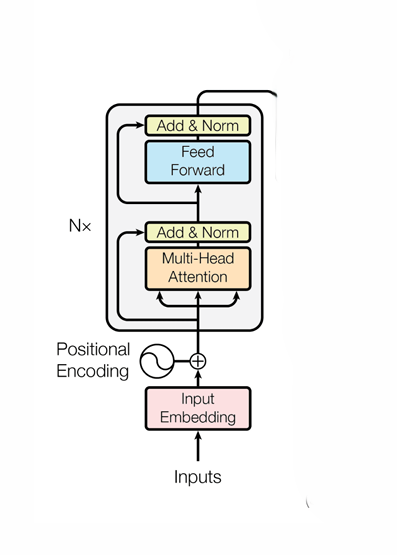

### 🔷 Transformer Encoder Block

An **Encoder Block** is a fundamental building block of the Transformer encoder. It transforms input embeddings into meaningful contextual representations through layers of self-attention and feed-forward networks.
#### 🧱 Components of an Encoder Block:

1. **Multi-Head Self-Attention**
   - Each token attends to every other token in the sequence.
   - Helps the model understand contextual relationships.

2. **Add & Layer Normalization**
   - Applies a residual connection from the input and normalizes the result.

3. **Feed-Forward Network (FFN)**
   - Two linear layers with a ReLU activation in between.
   - Applied independently to each position.

4. **Add & Layer Normalization**
   - Another residual connection followed by normalization.

In [ ]:
class EncoderBlock(nn.module):
    def __init__(self, self_attention_block: MultiHeadAttention, feed_forward_block: FeedForwardNetwork, dropout: float) -> None:
        super().__init__()
        self.self_attention_block = self_attention_block
        self.feed_forward_block = feed_forward_block
        # Creating two residual connections for the self-attention and feed-forward layers
        self.residual_attention = nn.ModuleList([
            ResidualConnection(dropout),
            ResidualConnection(dropout)
        ])

    def forward(self, x, src_mask):
        # mask is used to prevent attention to padding tokens
        # So it won't look at future tokens during training

        # Applying the first residual connection over the self-attention block.
        # The ResidualConnection class expects a function that takes 'x' as input.
        # However, our self-attention block also needs an additional argument: the 'src_mask'.
        # To handle this, we use a lambda function to "wrap" the attention call.
        # This lambda takes 'x' and internally calls the self_attention_block with x as Q, K, V and src_mask.
        # This allows ResidualConnection to normalize x first, then call the lambda(x), and finally apply residual addition.
        # so basically we are passing a function that takes x as input
        x = self.residual_attentioin[0](x, lambda x: self.self_attention_block(x, x, x, src_mask))
        x = self.residual_attention[1](x, self.feed_forward_block)
        return x

#### Full Encoder

#### 🧱 `EncoderBlock` – Single Layer
- Represents **one layer** of the Transformer encoder.
- Contains:
  - Multi-Head Self-Attention
  - Feed-Forward Network (FFN)
  - Residual Connections + Layer Normalization
- Processes the input sequence **once**, transforming it based on contextual relationships.

#### 🔶 `Encoder`
An Encoder is the stack of multiple EncoderBlocks (usually 6 or more in the original paper).
It processes the input sequence through multiple stages (blocks), one after the other.

#### 🔷 EncoderBlock vs Encoder in Transformer

In a Transformer architecture, the **Encoder** is made up of multiple **EncoderBlocks** stacked on top of each other.

In [ ]:
class Encoder(nn.Module):
    def __init__(self, layers: nn.ModuleList) -> None:
        super().__init__()
        self.layers = layers
        self.norm = LayerNormalization()  # Final layer normalization

    def forward(self, x, mask):
        for layer in self.layers:
            x = layer(x, mask)
        return self.norm(x)

### Decoder Block

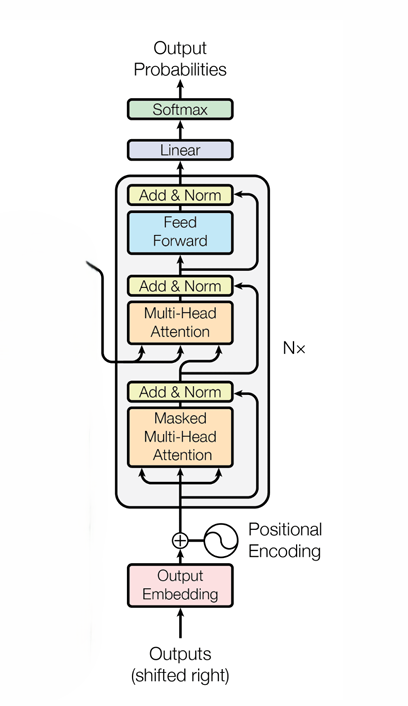

In [ ]:
class DecoderBlock(nn.Module):
    def __init__(self, self_attention_block: MultiHeadAttention, cross_attention_block: MultiHeadAttention, feed_forward_block: FeedForwardNetwork, dropout: float) -> None:
        super().__init__()
        self.self_attention_block = self_attention_block
        self.cross_attention_block = cross_attention_block
        self.feed_forward_block = feed_forward_block
        self.residual_connections = nn.ModuleList([
            ResidualConnection(dropout),
            ResidualConnection(dropout),
            ResidualConnection(dropout)
        ])

    def forward(self, x, encoder_output, src_mask, tgt_mask):
        # In this partular transformer, we are doing a translation task
        # So we have two masks for source and target languages
        x = self.residual_connections[0](x, lambda x: self.self_attention_block(x, x, x, tgt_mask)) # (query, key, value, mask)
        x = self.residual_connections[1](x, lambda x: self.cross_attention_block(x, encoder_output, encoder_output, src_mask))
        x = self.residual_connections[2](x, self.feed_forward_block)
        return x
        

### Full Decoder

In [ ]:
class Decoder(nn.Module):
    def __init__(self, layers:nn.ModuleList) -> None:
        super().__init__()
        self.layers = layers
        self.norm = LayerNormalization()
    
    def forward(self, x, encoder_output, src_mask, tgt_mask):
        for layer in self.layers:
            x = layer(x, encoder_output, src_mask, tgt_mask)
        return self.norm(x)

### Projection Layer

##### 🔄 Projection Layers in Transformer

A **projection layer** is a linear transformation (`nn.Linear`) that maps input vectors to another space — changing dimensionality or orientation. In Transformers, it's used in several key places:

##### 🧠 1. In Multi-Head Attention (Q, K, V)

Each input vector is linearly projected to form:

- **Query (Q)**: `X @ W_Q`
- **Key (K)**: `X @ W_K`
- **Value (V)**: `X @ W_V`

These projections allow each head to focus on different subspace representations.

##### 🔄 2. After Concatenating Attention Heads

All attention head outputs are concatenated and passed through a final projection:

```text
Output = Concat(head1, ..., headN) @ W_O


In [ ]:
class ProjectionLayer(nn.Module):
    def __init__(self, d_model:int, vocab_size:int) -> None:
        super().__init___()
        self.proj = nn.Linear(d_model, vocab_size)  # Linear projection layer

    def forward(self, x):
        # This layer is used to project the output of the decoder to the vocabulary size
        # (Batch, Seq_Len, d_model) --> (Batch, Seq_Len, vocab_size)
        return torch.log_softmax(self.proj(x), dim=-1)  # Log softmax for better numerical stability

### Transformer Block

In [ ]:
class Transformer(nn.Module):
    def __init__(self, encoder:Encoder, decoder:Decoder, src_embed: InputEmbedding, tgt_embed: InputEmbedding, src_pos:PositionalEncoding, tgt_pos:PositionalEncoding, projection_layer: ProjectionLayer) -> None:
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.src_embed = src_embed
        self.tgt_embed = tgt_embed
        self.src_pos = src_pos
        self.tgt_pos = tgt_pos
        self.projection_layer = projection_layer
    
    # This method encodes the source sequence
    # It applies the source embedding and positional encoding, then passes it through the encoder
    def encode(self, src, src_mask):
        src = self.src_embed(src)
        src = self.src_pos(src)
        return self.encoder(src, src_mask)
    
    # This method decodes the target sequence
    # It applies the target embedding and positional encoding, then passes it through the decoder
    def decode(self, encoder_output, src_mask, tgt, tgt_mask):
        tgt = self.tgt_embed(tgt)
        tgt = self.tgt_pos(tgt)
        return self.decoder(tgt, encoder_output, src_mask, tgt_mask)
    
    # This method projects the decoder output to the vocabulary size
    # It applies the projection layer to the decoder output
    def project(self, x):
        return self.projection_layer(x)

### Building the Transformer function

##### 🎯 Xavier Uniform Initialization (Glorot Uniform)

**Xavier Uniform** is a weight initialization technique designed to keep the variance of activations consistent across layers, helping deep networks train effectively.

##### 📐 Formula

Weights are sampled from:

$$
W \sim \mathcal{U} \left( -\sqrt{\frac{6}{n_{\text{in}} + n_{\text{out}}}},\ \sqrt{\frac{6}{n_{\text{in}} + n_{\text{out}}}} \right)
$$

- \( n_{\text{in}} \): number of input units (fan-in)  
- \( n_{\text{out}} \): number of output units (fan-out)


##### 🧠 Why Use It?

- Prevents **vanishing/exploding gradients**
- Promotes **faster convergence**
- Ideal for **Tanh**, **Sigmoid**, and also works with **ReLU**


In [ ]:
# This function builds a transformer model for translation tasks
# can be used for other tasks as well
# d_model: Dimension of the model (embedding size) 512 as per the original paper
# N : Number of encoder/decoder layers (6 as per the original paper)
# h: Number of attention heads (8 as per the original paper)
# d_ff: Dimension of the feed-forward network (2048 as per the original paper)
# dropout: Dropout rate (0.1 as per the original paper)

def build_transformer(src_vocab_size:int, tgt_vocab_size:int, src_seq_len:int, tgt_src_len:int, d_model:int=512, N:int=6, h:int=8, dropout:float=0.1, d_ff:int=2048) -> Transformer:
    
    # Creating input and target embeddings
    src_embed = InputEmbedding(d_model, src_vocab_size)
    tgt_embed = InputEmbedding(d_model, tgt_vocab_size)

    # Creating positional encodings for source and target sequences
    src_pos = PositionalEncoding(d_model, src_seq_len, dropout)
    tgt_pos = PositionalEncoding(d_model, tgt_src_len, dropout)

    # Creating Encoder blocks
    encoder_blocks = []
    for _ in range(N):
        encoder_self_atttention_block = MultiHeadAttention(d_model, h, dropout)
        feed_forward_block = FeedForwardNetwork(d_model, d_ff, dropout)
        encoder_block = EncoderBlock(encoder_self_atttention_block, feed_forward_block, dropout)
        encoder_blocks.append(encoder_block)

    # Creating the decoder blocks
    decoder_blocks = []
    for _ in range(N):
        decoder_self_attention_block = MultiHeadAttention(d_model, h, dropout)
        decoder_cross_attention_block = MultiHeadAttention(d_model, h, dropout)
        feed_forward_block = FeedForwardNetwork(d_model, d_ff, dropout)
        decoder_block = DecoderBlock(decoder_self_attention_block, decoder_cross_attention_block, feed_forward_block, dropout)
        decoder_blocks.append(decoder_block)
    
    # Creating the encoder and decoder
    encoder = Encoder(nn.ModuleList(encoder_blocks))
    decoder = Decoder(nn.ModuleList(decoder_blocks))

    # Creating the projection layer
    projection_layer = ProjectionLayer(d_model, tgt_vocab_size)

    # Creating the transformer model
    transformer = Transformer(encoder, decoder, src_embed, tgt_embed, src_pos, tgt_pos, projection_layer)

    # Initializing the paramerters
    # It makes training more stable and faster by not starting from random values 
    for p in transformer.parameters():
        if p.dim() > 1:  # Only initialize weights, not biases
            nn.init.xavier_uniform_(p)  # Xavier uniform initialization
    
    return transformer

## Dataset Preparation

### Tokenizer Init

In [ ]:
from datasets import load_dataset
from tokenizers import Tokenizer
from torch.utils.data import Dataset, dataloader, random_split

from tokenizers.models import BPE, WordLevel
from tokenizers.trainers import BpeTrainer, WordLevelTrainer
from tokenizers.pre_tokenizers import Whitespace, ByteLevel
from pathlib import Path


In [ ]:
# Each item in the datset is a pair of sentences
# This function extract one particular language from the dataset
def get_all_sentences(ds, lang):
    for item in ds:
        yield item['translation'][lang]

In [ ]:
# This function checks if a tokenizer exists for the given language
# If it does not exist, it builds a new tokenizer using the provided dataset and configuration
def get_or_build_tokenizer(config, ds, lang):
    tokenizer_path = Path(config['tokenizer_path'].format(lang=lang))
    if not Path.exists(tokenizer_path):
        tokenizer = Tokenizer(WordLevel(unk_token="[UNK]")) # if the token is unknown, we will use [UNK] token
        tokenizer.pre_tokenizer = Whitespace()
        # UNK-PAD-SOS-EOS tokens are used for unknown, padding, start of sequence and end of sequence tokens
        trainer = WordLevelTrainer(special_tokens=["[UNK]", "[PAD]", "[SOS]", "[EOS]"], min_frequency=2)
        tokenizer.train_from_iterator(get_all_sentences(ds, lang), trainer=trainer)
        tokenizer.save(str(tokenizer_path))
    else:
        tokenizer = Tokenizer.from_file(str(tokenizer_path))
    return tokenizer

In [ ]:
# This will load the dataset
def get_ds(config):
    ds_raw = load_dataset('opus_books', f'{config['lang_src']}-{config['lang_tgt']}', split='train')

    # Build tokenizers
    tokenizer_src = get_or_build_tokenizer(config, ds_raw, config['lang_src'])
    tokenizer_tgt = get_or_build_tokenizer(config, ds_raw, config['lang_tgt'])

    # creating training and validation datasets
    ds_train_size = int(0.9 * len(ds_raw))  # 90% for training
    val_ds_size = len(ds_raw) - ds_train_size  # 10% for validation
    train_ds_raw, val_ds_raw = random_split(ds_raw, [ds_train_size, val_ds_size])


### Dataset handling

In [ ]:
from typing import Any

class BilingualDataset(Dataset):
    def __init__(self, ds, tokenizer_src, tokenizer_tgt, src_lang, tgt_lang, seq_len) -> None:
        super().__init__()
        self.ds = ds
        self.tokenizer_src = tokenizer_src
        self.tokenizer_tgt = tokenizer_tgt
        self.src_lang = src_lang
        self.tgt_lang = tgt_lang

        self.sos_token = torch.Tensor([tokenizer_src.token_to_id(['[SOS]'])], dtype=torch.int64)
        self.eos_token = torch.Tensor([tokenizer_src.token_to_id(['[EOS]'])], dtype=torch.int64)
        self.pad_token = torch.Tensor([tokenizer_src.token_to_id(['[PAD]'])], dtype=torch.int64)

    def __len__(self):
        return len(self.ds)
    
    def __getitem__(self, index:Any) -> Any:
        src_target_pair = self.ds[index]
        src_text = src_target_pair['translation'][self.src_lang]
        tgt_text = src_target_pair['translation'][self.tgt_lang]

        enc_input_token = self.tokenizer_src.encode(src_text).ids
        dec_input_token = self.tokenizer_tgt.encode(tgt_text).ids

        # model always works with fixed sequence length in every sentence
        # So sentences that aren't having enough tokens will be padded with [PAD] token
        enc_num_padding_token = self.seq_len - len(enc_input_token) - 2  # -2 for [SOS] and [EOS]
        dec_num_padding_token = self.seq_len - len(dec_input_token) - 1 # -1 for [SOS]
        
         
